# 1) Chargement des données

In [161]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns


In [162]:
DATA_DIR = Path() / "data"

def load_file(file, sep=',', skiprows=0) -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / file, 
        sep=sep,
        low_memory=False,
        encoding='utf-8',
        skiprows=skiprows,
        na_values=['..', 'NA', 'N/A', '']
    ).dropna(how='all')

    show_info(df)
    return df

def show_info(df):
    print("SHAPE:")
    print(df.shape)

    print("\n--------")
    print("INFO:")
    df.info()

    print("\n--------")
    print("SAMPLE:")
    display(df.head())

    print("\n--------")
    print("MISSING VALUES:")
    missing = pd.DataFrame({
        'count': df.isnull().sum(),
        'percentage': (df.isnull().mean() * 100).round(2)
    })
    display(missing[missing['count'] > 0])  # only shows columns WITH missing values

    print("\n--------")
    print("UNIQUE VALUES:")
    print(df.nunique())

    print("\n--------")
    print("STATISTICAL SUMMARY:")
    display(df.describe())


In [ ]:
df = load_file("billets.csv", sep=';')

SHAPE:
(1500, 7)

--------
INFO:
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB

--------
SAMPLE:


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54



--------
MISSING VALUES:


,count,percentage
margin_low,37,2.47



--------
UNIQUE VALUES:
is_genuine        2
diagonal        159
height_left     155
height_right    170
margin_low      285
margin_up       123
length          336
dtype: int64

--------
STATISTICAL SUMMARY:


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


# 2) Analyse exploratoire (EDA)


In [164]:
num_columns = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

### bar charts

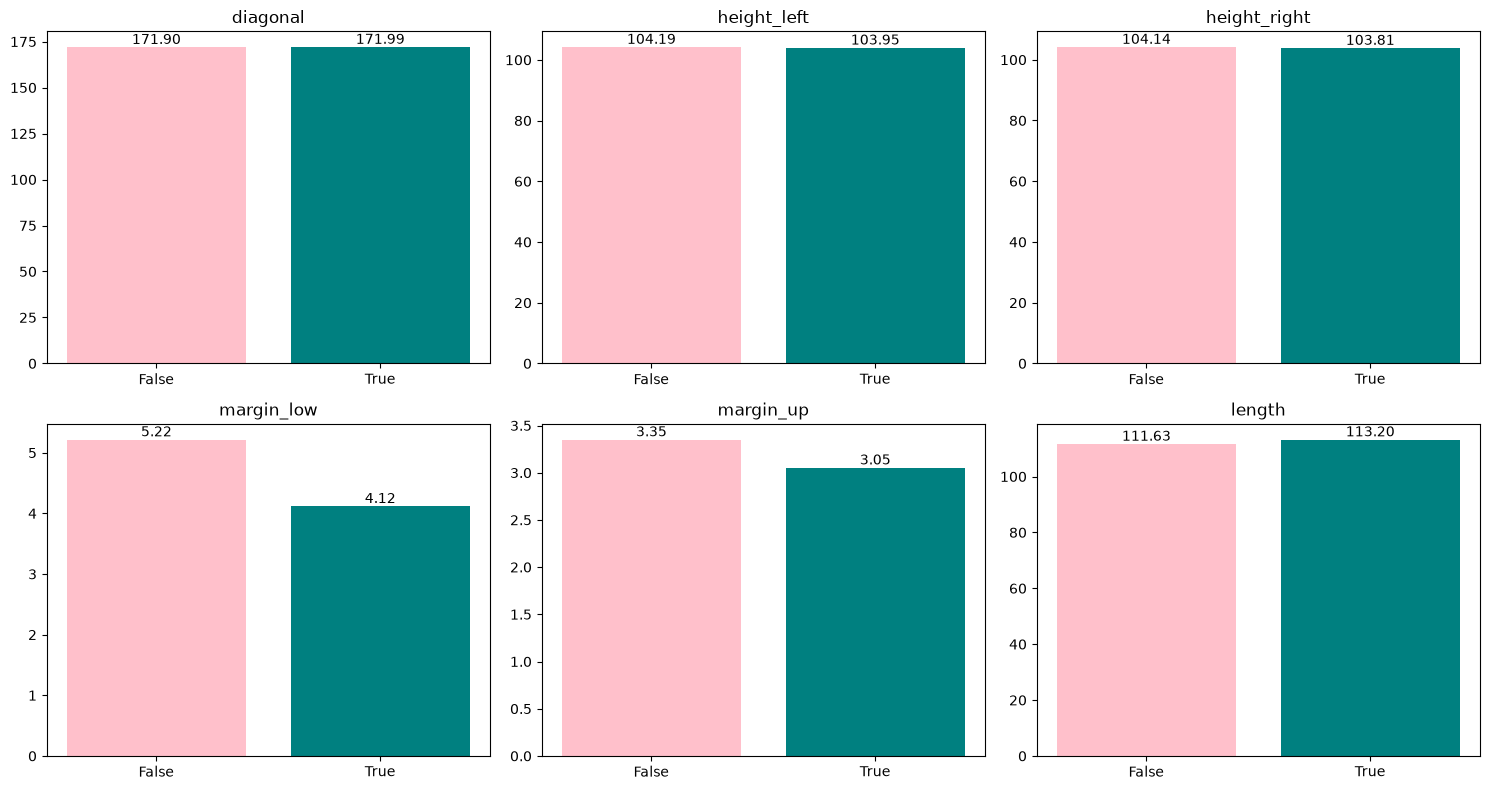

In [165]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    mean = df.groupby('is_genuine')[col].mean()
    bars = axes[i].bar(
        ['False', 'True'],
        mean.values,
        color=['pink', 'teal']
    )
    axes[i].set_title(col)

    for bar in bars:
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,  # x: center of bar
            bar.get_height(),                     # y: top of bar
            f'{bar.get_height():.2f}',            # label: 2 decimal places
            ha='center',  # horizontal alignment
            va='bottom'   # sit just above the bar
        )

plt.tight_layout()
plt.show()

### boxplot

/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_34216/2903458328.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(['False', 'True'])
/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_34216/2903458328.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(['False', 'True'])
/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_34216/2903458328.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(['False', 'True'])
/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_34216/2903458328.py:16: UserWarning: set_ticklabels() should only

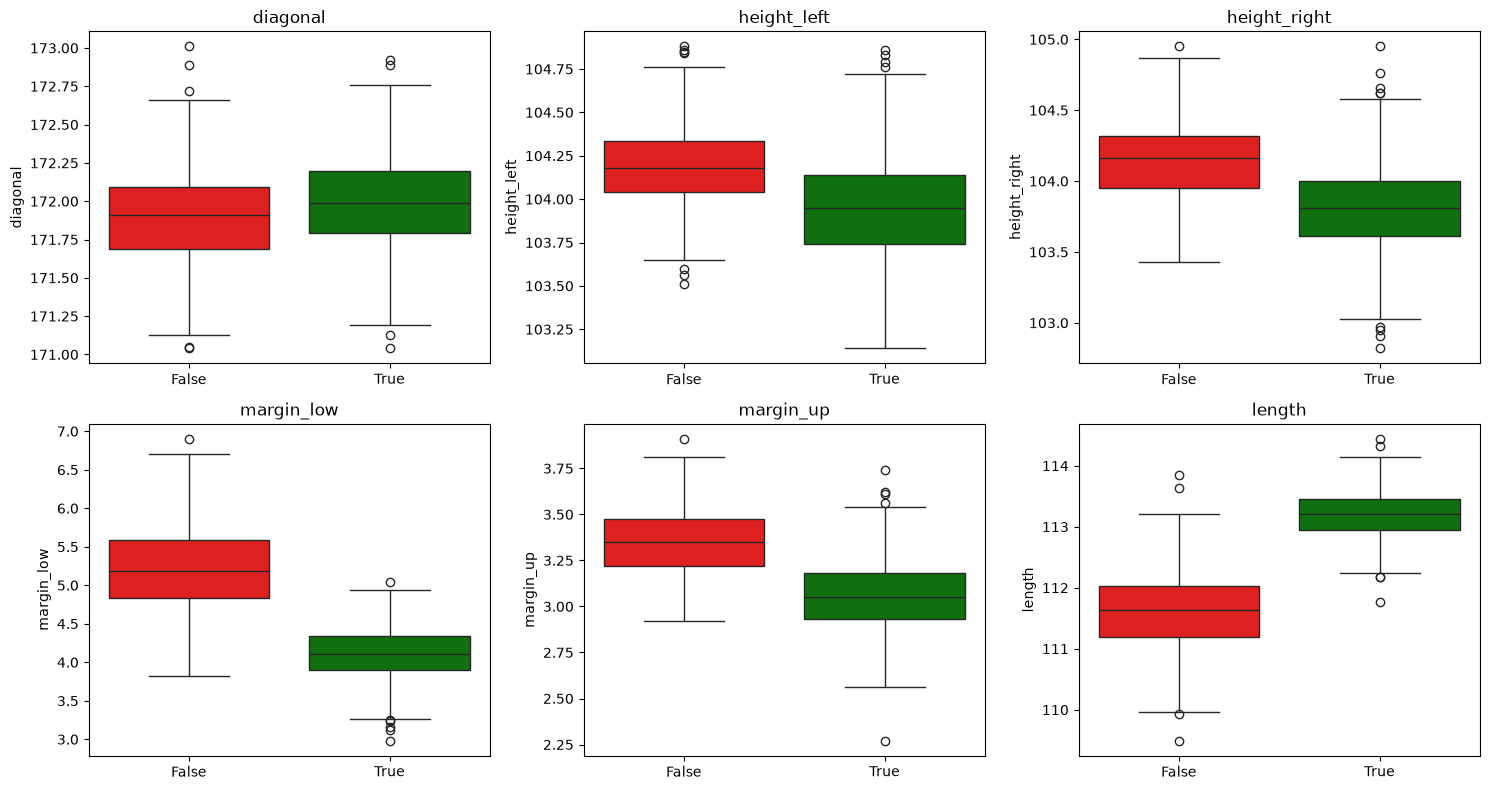

In [166]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    sns.boxplot(
        data=df,
        x='is_genuine',
        hue='is_genuine',
        y=col,
        legend=False,
        palette=['red', 'green'],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['False', 'True'])

plt.tight_layout()
plt.show()

### heatmap

No multicollinearity detected (all correlations below 0.8)

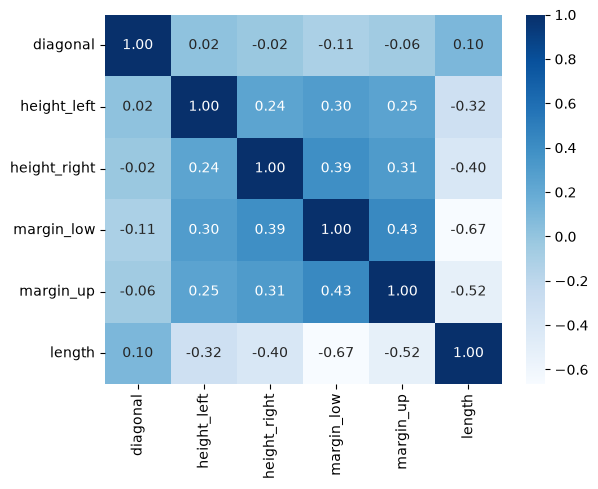

In [167]:
sns.heatmap(
    df[num_columns].corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f'
)
plt.show()

### Correlation of each feature WITH the target

"diagonal" has the weakest correlation with the target variable "is_genuine"

In [168]:
print(df[num_columns].corrwith(df['is_genuine'].astype(int)).sort_values(ascending=False))

length          0.849285
diagonal        0.132756
height_left    -0.379833
height_right   -0.485092
margin_up      -0.606262
margin_low     -0.783032
dtype: float64


# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

In [169]:
X = df[num_columns] # Toutes les colonnes sauf la cible
y = df['is_genuine'] # La colonne cible

Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

### Train test split

In [170]:
from sklearn.model_selection import train_test_split

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=test_size, 
    stratify=y, 
    random_state=42
)

In [171]:
print(f"Train size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass distribution in train:")
print(y_train.value_counts(normalize=True))
print(f"\nClass distribution in test:")
print(y_test.value_counts(normalize=True))

Train size: 1200 (80%)
Test size: 300 (20%)

Class distribution in train:
is_genuine
True     0.666667
False    0.333333
Name: proportion, dtype: float64

Class distribution in test:
is_genuine
True     0.666667
False    0.333333
Name: proportion, dtype: float64


Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

### Imputation by median

Steps:
- Fit only on X_train
- Transform X_train and X_test

In [172]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=num_columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=num_columns
)

In [173]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diagonal      1200 non-null   float64
 1   height_left   1200 non-null   float64
 2   height_right  1200 non-null   float64
 3   margin_low    1200 non-null   float64
 4   margin_up     1200 non-null   float64
 5   length        1200 non-null   float64
dtypes: float64(6)
memory usage: 56.4 KB


In [174]:
X_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diagonal      300 non-null    float64
 1   height_left   300 non-null    float64
 2   height_right  300 non-null    float64
 3   margin_low    300 non-null    float64
 4   margin_up     300 non-null    float64
 5   length        300 non-null    float64
dtypes: float64(6)
memory usage: 14.2 KB


### StandardScaler

#### on train data

In [175]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_columns)
X_train_scaled.describe().round(2)

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.07,-2.97,-3.13,-2.11,-3.82,-3.65
25%,-0.67,-0.71,-0.66,-0.69,-0.70,-0.74
50%,0.00,0.03,0.00,-0.26,-0.05,0.33
75%,0.67,0.66,0.72,0.59,0.68,0.75
max,3.50,2.83,3.20,3.71,3.28,2.03


#### on test data

In [176]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_columns)
X_test_scaled.describe().round(2)

,diagonal,height_left,height_right,margin_low,margin_up,length
count,300.00,300.00,300.00,300.00,300.00,300.00
mean,-0.02,-0.03,0.02,-0.05,-0.01,0.06
std,1.08,0.99,1.05,1.05,1.02,1.01
min,-2.73,-2.61,-3.41,-2.32,-2.56,-2.81
25%,-0.74,-0.74,-0.63,-0.77,-0.76,-0.70
50%,-0.05,0.04,0.00,-0.26,-0.01,0.39
75%,0.81,0.64,0.75,0.50,0.73,0.83
max,3.10,2.66,2.61,3.19,2.85,1.68


# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

## Logistic Regression

In [177]:
from sklearn.linear_model import LogisticRegression

# 1) Initialisez une régression logistic.
model_lr = LogisticRegression(
    max_iter=1000, 
    random_state=42
)

# 2) Entrainez le modèle avec vos données X_train et y_train
model_lr.fit(X_train_scaled, y_train)

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.
y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_lr_prob = model_lr.predict_proba(X_test_scaled)


## KNN

In [178]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)
y_pred_knn_prob = model_knn.predict_proba(X_test_scaled)


## Random Forest

In [179]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest doesn't need scaling

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_pred_rf_prob = model_rf.predict_proba(X_test)

## K-means

In [180]:
from sklearn.cluster import KMeans

model_kmeans = KMeans(
    n_clusters=2,
    random_state=42
)
model_kmeans.fit(X_train_scaled)
train_clusters = model_kmeans.predict(X_train_scaled)

# Check which group is identified as true/false bills
print(y_train[train_clusters == 0].mean()) 
print(y_train[train_clusters == 1].mean())  


0.015228426395939087
0.9851116625310173


In [181]:
mapping = {1: True, 0: False}

test_cluster = model_kmeans.predict(X_test_scaled)
y_pred_kmeans = np.array([mapping[c] for c in test_cluster])

compare_kmeans = pd.DataFrame({
    'actual': y_test,
    'pred': y_pred_kmeans
})
compare_kmeans

,actual,pred
803,True,True
1306,False,False
1263,False,False
38,True,True
257,True,True
...,...,...
1445,False,False
795,True,True
301,True,True
1241,False,False


# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

In [182]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

LABELS = ['Fake', 'Real']

def show_cm(cm):
    display = ConfusionMatrixDisplay(cm)
    display.plot(cmap='Blues')
    plt.show()

## Logistic Regression

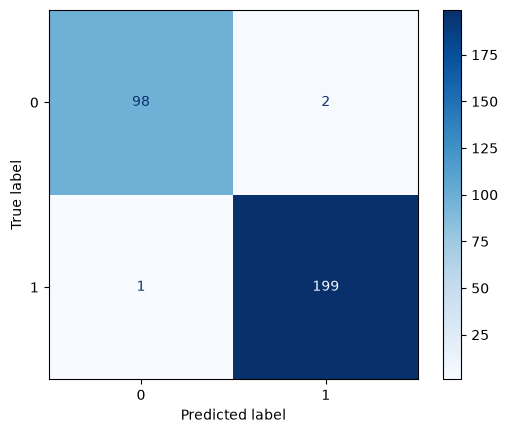

In [183]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=[False, True])
show_cm(cm_lr)

In [184]:
print(f"AUC score: {roc_auc_score(y_test, y_pred_lr_prob[:, 1]):.4f}")
print(classification_report(y_test, y_pred_lr, digits=4))

AUC score: 0.9995
              precision    recall  f1-score   support

       False     0.9899    0.9800    0.9849       100
        True     0.9900    0.9950    0.9925       200

    accuracy                         0.9900       300
   macro avg     0.9900    0.9875    0.9887       300
weighted avg     0.9900    0.9900    0.9900       300



## KNN

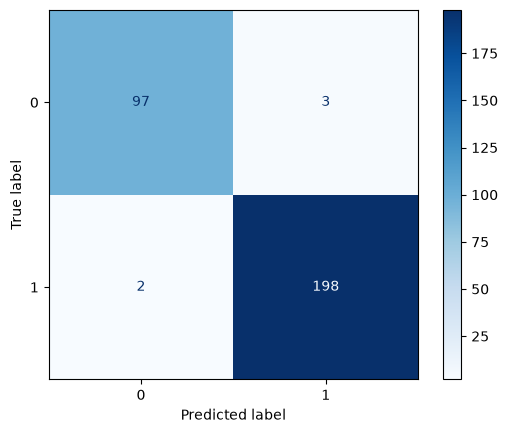

In [185]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
show_cm(cm_knn)

In [186]:
print(f"AUC score: {roc_auc_score(y_test, y_pred_knn_prob[:, 1]):.4f}")
print(classification_report(y_test, y_pred_knn))

AUC score: 0.9971
              precision    recall  f1-score   support

       False       0.98      0.97      0.97       100
        True       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



## Random Forest

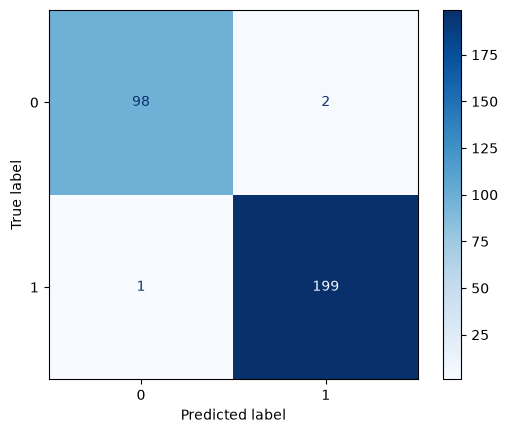

In [187]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
show_cm(cm_rf)

In [188]:
print(f"AUC score: {roc_auc_score(y_test, y_pred_rf_prob[:, 1]):.4f}")
print(classification_report(y_test, y_pred_rf))

AUC score: 0.9992
              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



<Axes: title={'center': 'Feature Importance'}>

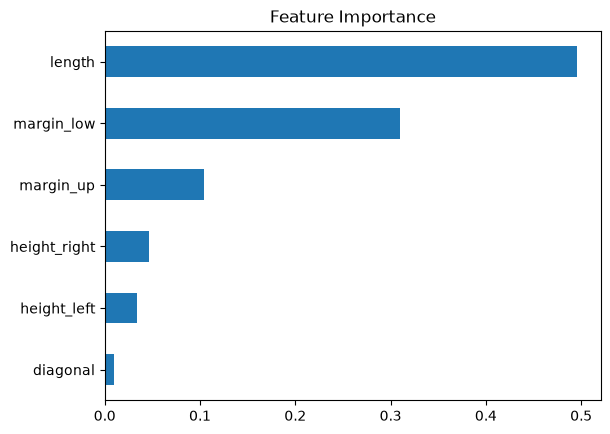

In [189]:
pd.Series(
    model_rf.feature_importances_, 
    index=num_columns
).sort_values().plot(kind='barh', title='Feature Importance')

## K-means

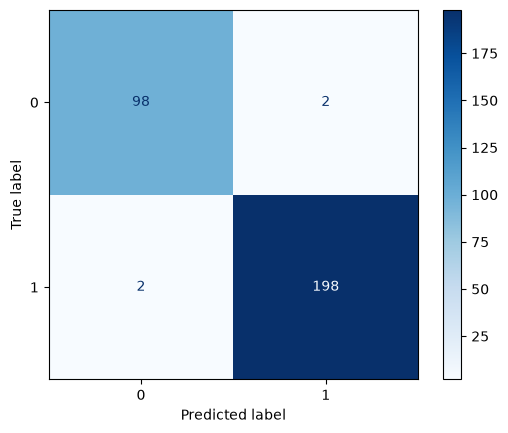

In [190]:
cm_keans = confusion_matrix(y_test, y_pred_kmeans)
show_cm(cm_keans)

In [191]:
print(f"Accuracy score: {accuracy_score(y_test, y_pred_kmeans):.4f}")

recall_kmeans = recall_score(y_test, y_pred_kmeans, pos_label=False)
print(f"K-Means Recall False: {recall_kmeans:.4f}")

print(classification_report(y_test, y_pred_kmeans))

Accuracy score: 0.9867
K-Means Recall False: 0.9800
              precision    recall  f1-score   support

       False       0.98      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



# Tunning

In [192]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

## Logistic Regression

### Testing with GridSearchCV

In [193]:
param_grid = {
    'C': [0.1, 1, 5, 10],
    'max_iter': [1000, 2000, 3000],
    'class_weight': [
        {False: 2, True: 1},
        {False: 3, True: 1},
        {False: 5, True: 1},
        'balanced'
    ]
}

scorer = make_scorer(recall_score, pos_label=False)

tuning_model_lr = LogisticRegression(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=tuning_model_lr,
    param_grid=param_grid,
    cv=5,
    scoring=scorer
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best param: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best estimator: {grid_search.best_estimator_}")

Best param: {'C': 1, 'class_weight': {False: 5, True: 1}, 'max_iter': 1000}
Best score: 0.9875
Best estimator: LogisticRegression(C=1, class_weight={False: 5, True: 1}, max_iter=1000,
                   random_state=42)


### Fit and evaluate

In [194]:
best_lr = grid_search.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_scaled)
y_pred_prob_best_lr = best_lr.predict_proba(X_test_scaled)

In [195]:
recall_false_baseline = recall_score(y_test, y_pred_lr, pos_label=False)
recall_false_tuned = recall_score(y_test, y_pred_best_lr, pos_label=False)

print(f"Baseline recall (Faux): {recall_false_baseline:.4f}")
print(f"Tuned recall (Faux):    {recall_false_tuned:.4f}")

Baseline recall (Faux): 0.9800
Tuned recall (Faux):    1.0000


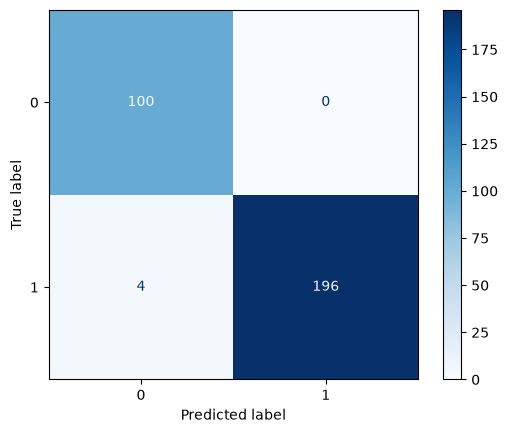

In [196]:
cm_lr = confusion_matrix(y_test, y_pred_best_lr, labels=[False, True])
show_cm(cm_lr)

In [197]:
print(f"AUC score: {roc_auc_score(y_test, y_pred_prob_best_lr[:, 1]):.4f}")
print(classification_report(y_test, y_pred_best_lr, digits=4))


AUC score: 0.9995
              precision    recall  f1-score   support

       False     0.9615    1.0000    0.9804       100
        True     1.0000    0.9800    0.9899       200

    accuracy                         0.9867       300
   macro avg     0.9808    0.9900    0.9851       300
weighted avg     0.9872    0.9867    0.9867       300



> -> Better results!

### Tuning threshold

In [198]:
from sklearn.metrics import precision_recall_curve

# Probabilities for the "fake" class (index 0)
y_prob_fake = y_pred_prob_best_lr[:, 0]

# y_test needs to be binary 0/1 for this curve
# "positive" here = fake (False label)
y_test_binary = (~y_test).astype(int)  # True if fake

precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_prob_fake)

# Find threshold where recall_fake = 1.0 (or as high as possible)
# while keeping precision acceptable
for p, r, t in zip(precisions, recalls, thresholds):
    if r == 1.0:
        print(f"Threshold: {t:.4f} | Precision (fake): {p:.4f} | Recall (fake): {r:.4f}")

Threshold: 0.0000 | Precision (fake): 0.3333 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3344 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3356 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3367 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3378 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3390 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3401 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3413 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3425 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3436 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3448 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3460 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3472 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fake): 0.3484 | Recall (fake): 1.0000
Threshold: 0.0000 | Precision (fak

In [199]:
threshold = 0.7636

# Probability of being fake (class index 0)
y_prob_fake = y_pred_prob_best_lr[:, 0]

# Flag as fake if probability >= threshold
y_pred_custom = y_prob_fake >= threshold  # True = predicted fake

# Convert back to your label space (False = fake in your encoding)
y_pred_custom_labels = ~y_pred_custom

print(classification_report(y_test, y_pred_custom_labels, digits=4))

              precision    recall  f1-score   support

       False     0.9901    1.0000    0.9950       100
        True     1.0000    0.9950    0.9975       200

    accuracy                         0.9967       300
   macro avg     0.9950    0.9975    0.9963       300
weighted avg     0.9967    0.9967    0.9967       300



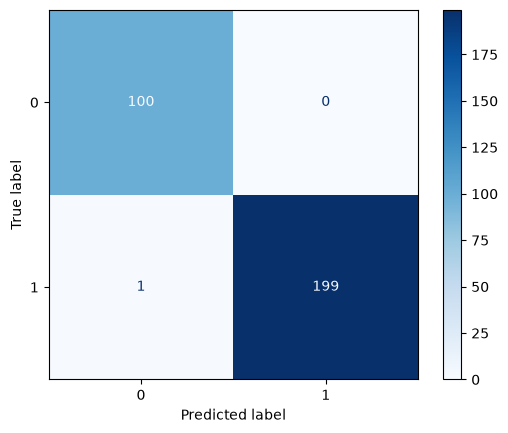

In [200]:
show_cm(confusion_matrix(y_test, y_pred_custom_labels))

> -> Even better with threshold tuning!

## KNN

In [201]:
param_grid_knn = {
    'n_neighbors': range(1, 20, 2),  
    'metric': ['euclidean', 'manhattan']
}

tuning_model_knn = KNeighborsClassifier()

gs_knn = GridSearchCV(
    estimator=tuning_model_knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring=scorer
)

gs_knn.fit(X_train_scaled, y_train)

print(f"Best estimator: {gs_knn.best_estimator_}")
print(f"Best score: {gs_knn.best_score_}")
print(f"Best param: {gs_knn.best_params_}")

Best estimator: KNeighborsClassifier(metric='euclidean')
Best score: 0.9800000000000001
Best param: {'metric': 'euclidean', 'n_neighbors': 5}


Baseline recall (Faux): 0.9700
Tuned recall (Faux):    0.9700
AUC score: 0.9971
              precision    recall  f1-score   support

       False       0.98      0.97      0.97       100
        True       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



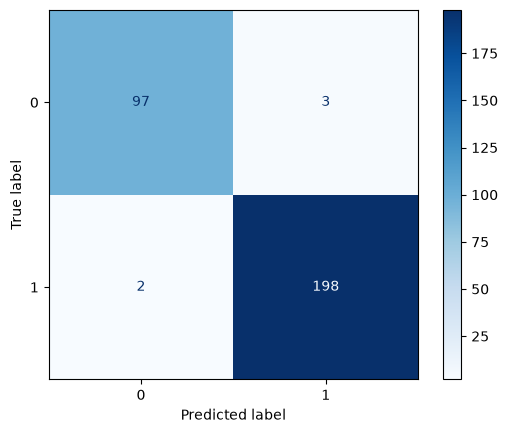

In [202]:
best_knn = gs_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test_scaled)
y_pred_prob_best_knn = best_knn.predict_proba(X_test_scaled)

recall_false_baseline_knn = recall_score(y_test, y_pred_knn, pos_label=False)
recall_false_tuned_knn = recall_score(y_test, y_pred_best_knn, pos_label=False)

print(f"Baseline recall (Faux): {recall_false_baseline_knn:.4f}")
print(f"Tuned recall (Faux):    {recall_false_tuned_knn:.4f}")
print(f"AUC score: {roc_auc_score(y_test, y_pred_prob_best_knn[:, 1]):.4f}")
print(classification_report(y_test, y_pred_best_knn))

cm_best_rf = confusion_matrix(y_test, y_pred_best_knn)
show_cm(cm_best_rf)

> -> Doesn't have better results!

## Random Forest

In [203]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],      
    'max_depth': [None, 5, 10, 20],       
    'min_samples_split': [2, 5, 10]   
}

tuning_model_rf = RandomForestClassifier(random_state=42)

gs_rf = GridSearchCV(
    estimator=tuning_model_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring=scorer
)

gs_rf.fit(X_train, y_train)

print(f"Best estimator: {gs_rf.best_estimator_}")
print(f"Best score: {gs_rf.best_score_}")
print(f"Best param: {gs_rf.best_params_}")

Best estimator: RandomForestClassifier(min_samples_split=5, n_estimators=300, random_state=42)
Best score: 0.9800000000000001
Best param: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}


Baseline recall (Faux): 0.9800
Tuned recall (Faux):    0.9800
AUC score: 0.9992
              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



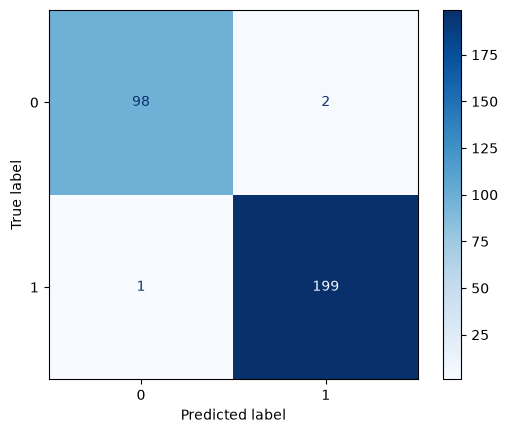

In [204]:
best_rf = gs_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_pred_prob_best_rf = best_rf.predict_proba(X_test)

recall_false_baseline_rf = recall_score(y_test, y_pred_rf, pos_label=False)
recall_false_tuned_rf = recall_score(y_test, y_pred_best_rf, pos_label=False)

print(f"Baseline recall (Faux): {recall_false_baseline_rf:.4f}")
print(f"Tuned recall (Faux):    {recall_false_tuned_rf:.4f}")
print(f"AUC score: {roc_auc_score(y_test, y_pred_prob_best_rf[:, 1]):.4f}")
print(classification_report(y_test, y_pred_best_rf))

cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
show_cm(cm_best_rf)

> -> No better than the untuned model

# Summary

### On Recall

/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_34216/753492441.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  axes = sns.barplot(


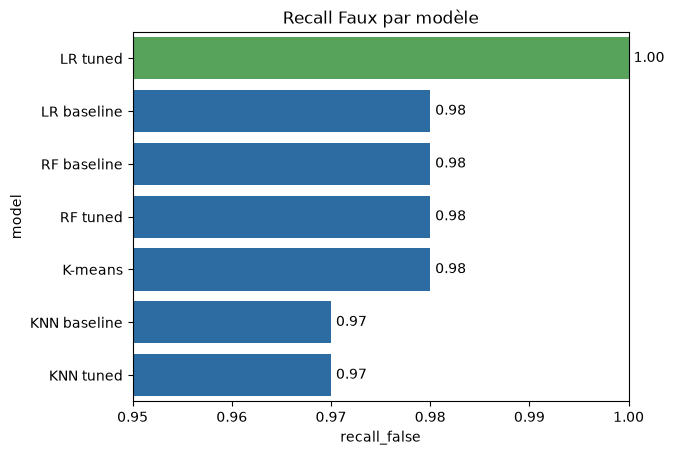

In [205]:
df_recall_false = pd.DataFrame({
    'model': [
        'LR baseline', 
        'LR tuned',
        'KNN baseline',
        'KNN tuned',
        'RF baseline',
        'RF tuned',
        'K-means'
    ],
    'recall_false': [
        recall_score(y_test, y_pred_lr, pos_label=False),
        recall_score(y_test, y_pred_custom_labels, pos_label=False),
        recall_score(y_test, y_pred_knn, pos_label=False),
        recall_score(y_test, y_pred_best_knn, pos_label=False),
        recall_score(y_test, y_pred_rf, pos_label=False),
        recall_score(y_test, y_pred_best_rf, pos_label=False),
        recall_score(y_test, y_pred_kmeans, pos_label=False),
    ]
})

df_recall_false = df_recall_false.sort_values('recall_false', ascending=False)

palette = ["#186EB6" if 'LR tuned' not in model else '#4CAF50' 
           for model in df_recall_false['model']]

axes = sns.barplot(
    df_recall_false,
    x='recall_false',
    y='model',
    palette=palette
)

for bar in axes.patches:
    axes.text(
        bar.get_width() + 0.0005,           
        bar.get_y() + bar.get_height() / 2,  
        f'{bar.get_width():.2f}',  # label
        ha='left',    # sit just after the bar
        va='center'   # vertically centered
    )

axes.set_xlim(0.95, 1.0)
axes.set_title("Recall Faux par modèle")

plt.show()

### On AUC

/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_34216/2874612756.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  axes = sns.barplot(


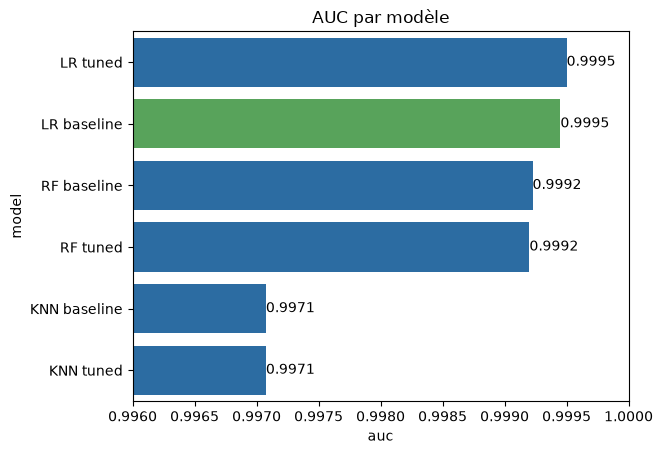

In [206]:
df_auc = pd.DataFrame({
    'model': [
        'LR baseline', 
        'LR tuned',
        'KNN baseline',
        'KNN tuned',
        'RF baseline',
        'RF tuned'
    ],
    'auc': [
        roc_auc_score(y_test, y_pred_lr_prob[:, 1]),
        roc_auc_score(y_test, y_pred_prob_best_lr[:, 1]),
        roc_auc_score(y_test, y_pred_knn_prob[:, 1]),
        roc_auc_score(y_test, y_pred_prob_best_knn[:, 1]),
        roc_auc_score(y_test, y_pred_rf_prob[:, 1]),
        roc_auc_score(y_test, y_pred_prob_best_rf[:, 1])
    ]
})

df_auc = df_auc.sort_values('auc', ascending=False)

palette = ["#186EB6" if 'LR baseline' not in model else '#4CAF50' 
           for model in df_auc['model']]

axes = sns.barplot(
    df_auc,
    x='auc',
    y='model',
    palette=palette
)

for bar in axes.patches:
    axes.text(
        bar.get_width(),           # x: end of bar
        bar.get_y() + bar.get_height() / 2,  # y: center of bar
        f'{bar.get_width():.4f}',  # label
        ha='left',    # sit just after the bar
        va='center'   # vertically centered
    )

axes.set_xlim(0.996, 1.0)
axes.set_title("AUC par modèle")

plt.show()

Tuned Logistic Regression model has the best results!

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [207]:
from sklearn.pipeline import make_pipeline
import joblib

pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(
        C=1, 
        class_weight={False: 5, True: 1}, 
        max_iter=1000, 
        random_state=42
    )
)

pipeline.fit(X_train, y_train)

joblib.dump(
    pipeline,
    "is_genuine_model.pkl"
)

['is_genuine_model.pkl']

### Checking

In [208]:
loaded_pipeline = joblib.load('is_genuine_model.pkl')

y_pred_prob_pipeline = loaded_pipeline.predict_proba(X_test)
proba_false = y_pred_prob_pipeline[:, 0]
y_pred_pipeline = np.where(proba_false >= threshold, False, True)

print(f"AUC: {roc_auc_score(y_test, y_pred_prob_pipeline[:, 1]):.4f}")
print(classification_report(y_test, y_pred_pipeline))

AUC: 0.9995
              precision    recall  f1-score   support

       False       0.99      1.00      1.00       100
        True       1.00      0.99      1.00       200

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

